Based on single LightGBM baseline with minimal FE, LB **0.447**:

https://www.kaggle.com/code/snufkin77/mcts-strength-relevant-baseline

DeepTables: Deep-learning Toolkit for Tabular data

https://github.com/DataCanvasIO/DeepTables

https://deeptables.readthedocs.io/en/latest/model_config.html#parameters

**Version 1**: single DeepTables NN baseline, LB **0.462**.

**Version 6**: single DeepTables NN, LB **0.448**; `ModelConfig(apply_gbm_features=True)`.

**Version 7**: single DeepTables NN, LB **0.438**; `ModelConfig(apply_gbm_features=True)`, `ModelConfig(nets=['dnn_nets'] + ['fm_nets'] + ['cin_nets'])`.

**Version 8**: same as Version 7 + scaling all numerical features to fix issue with divergence in the validation scores. Now overall CV rmse (0.4324) is closer to LB **0.435**. Note that in this version, the `fit_transform` method of scaler was performed on train and test data combined, which is not a good practice, although it does not violate any Kaggle rules.

**Version 9**: same as Version 8, but using scaler with `fit_transform` on the training data alone and then applying `transform` to the test data. CV 0.4319 | LB **0.438**.

**Version 10**: scaling way from Version 9, enable `LearningRateScheduler` with warmup `(LR_START = 1e-4)` on first epoch. CV 0.4343 | LB **0.434**.

**Version 11**: single CatBoost baseline. CV 0.4160 | LB 0.434.

**Version 12**: ensemble NN (CV 0.4343 | LB 0.434) + CatBoost (CV 0.4160 | LB 0.434), `ens_weights = {'nn': 0.50, 'ctb': 0.50}`. CV 0.4138 | LB **0.430**.

**Version 14**: adjust CatBoost params and ensemble weights; ensemble NN (CV 0.4343 | LB 0.434) + CatBoost (CV 0.4154 | LB 0.431), `ens_weights = {'nn': 0.40, 'ctb': 0.60}`. CV 0.4116 | LB **0.428**.

**Version 16**: same as Version 14, but due to non-deterministic behavior during training on GPU, the final score may slightly variate around. Based on this [contribution](https://www.kaggle.com/competitions/um-game-playing-strength-of-mcts-variants/discussion/542932), the DeepTables model saving-loading issue has been overcome. Now `Output` contains saved pretrained models that can be used for inference.

In [1]:
!pip install --no-index -U --find-links=/kaggle/input/tensorflow-2-15/tensorflow tensorflow==2.15.0
!pip install --no-index -U --find-links=/kaggle/input/deeptables-v0-2-5/deeptables-0.2.5 deeptables==0.2.5
!pip install --no-index -U --find-links=/kaggle/input/fix-deeptables/deeptables-0.2.6 deeptables==0.2.6

Looking in links: /kaggle/input/tensorflow-2-15/tensorflow
Processing /kaggle/input/tensorflow-2-15/tensorflow/tensorflow-2.15.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
Processing /kaggle/input/tensorflow-2-15/tensorflow/ml_dtypes-0.2.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (from tensorflow==2.15.0)
Processing /kaggle/input/tensorflow-2-15/tensorflow/wrapt-1.14.1-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (from tensorflow==2.15.0)
Processing /kaggle/input/tensorflow-2-15/tensorflow/tensorboard-2.15.1-py3-none-any.whl (from tensorflow==2.15.0)
Processing /kaggle/input/tensorflow-2-15/tensorflow/keras-2.15.0-py3-none-any.whl (from tensorflow==2.15.0)
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalli

In [2]:
import os
import math
import random
import warnings
import matplotlib.pyplot as plt
import numpy as np, pandas as pd, polars as pl
from sklearn.model_selection import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from colorama import Fore, Style

import tensorflow as tf, deeptables as dt
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers.legacy import Adam
from deeptables.models import DeepTable, ModelConfig
from deeptables.models import deepnets
from catboost import CatBoostRegressor

import numpy as np
import polars as pl
import pandas as pd
from pathlib import Path
import pickle
import matplotlib.pyplot as plt

import gc
import os
import sys
import io
import itertools
import re
# import shap
import joblib

from tqdm import tqdm

import kaggle_evaluation.mcts_inference_server

warnings.filterwarnings('ignore')
print('TensorFlow version:',tf.__version__+',',
      'GPU =',tf.test.is_gpu_available())
print('DeepTables version:',dt.__version__)

2024-11-17 12:04:18.982089: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-17 12:04:18.982151: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-17 12:04:18.983564: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.15.0, GPU = True
DeepTables version: 0.2.6


In [3]:
# seed = 42
# def seed_everything(seed):
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     random.seed(seed)
#     np.random.seed(seed)
#     tf.random.set_seed(seed)
# seed_everything(seed=seed)

# 前処理

In [4]:
test = pl.read_csv('/kaggle/input/um-game-playing-strength-of-mcts-variants/test.csv')
train = pl.read_csv('/kaggle/input/um-game-playing-strength-of-mcts-variants/train.csv')
concept = pl.read_csv('/kaggle/input/um-game-playing-strength-of-mcts-variants/concepts.csv')
submission = pl.read_csv('/kaggle/input/um-game-playing-strength-of-mcts-variants/sample_submission.csv')

In [5]:
def get_fold(train,random_state):
    n_splits = 5
    train = train.to_pandas()
    train["Game"] = train["LudRules"].str.split('"').str.get(1)
    group_col = train['Game']
    group_kfold = StratifiedGroupKFold(n_splits=n_splits,shuffle=True,random_state = random_state)
    # group_kfold = GroupKFold(n_splits=n_splits)

    # train["groupcut"] = np.abs(train["utility_agent1"] - (train["AdvantageP1"]*2-1))
    # train["groupbin"] = pd.cut(train["groupcut"],bins=10,labels=False)

    train["fold"] = -1
    # train["G"] = (train["utility_agent1"] == 1).astype("str")
    for fold, (train_idx, test_idx) in enumerate(group_kfold.split(train, train["utility_agent1"].astype("str"), groups=group_col),
                                                      ):
        train.loc[test_idx, "fold"] = fold
    # train = train.drop("groupcut",axis=1)
    # train = train.drop("groupbin",axis=1)
    # train = train.drop("G",axis=1)
    train = train.drop("Game",axis=1)
    train = pl.from_pandas(train)
    return train

In [6]:
# GameRulesetNameからゲーム名で特徴量を作成する
def extract_game_name(df):
    # 文字列長
    df = df.with_columns(pl.col("GameRulesetName").str.len_chars().alias("GameRulesetName_len"))
    # _で区切られた単語数
    df = df.with_columns(pl.col("GameRulesetName").str.count_matches("_").alias("GameRulesetName_count"))
    #アルファベットと数字の割合
    # train = train.with_columns([
    #     pl.col("GameRulesetName").str.count_match(r"[A-Za-z]").alias("alpha_count"),
    #     pl.col("GameRulesetName").str.count_match(r"\d").alias("digit_count")
    # ])

    # 頻出単語があるかないかフラグ
    frequent_word = ["Suggested"]
    for keyword in frequent_word:
        df = df.with_columns([
            pl.col("GameRulesetName").str.contains(keyword).cast(pl.Int8).alias(f"contains_{keyword.lower()}")
        ])
    frequent_word_column = [f"contains_{keyword.lower()}" for keyword in frequent_word]

    return df

frequent_word = ["Suggested"]
frequent_word_column = [f"contains_{keyword.lower()}" for keyword in frequent_word]

In [7]:
nomean_cols = []
for col,dtype in train.schema.items():
    # 列ですべての値が等しいカラムについては取り除く
    if dtype != pl.Utf8:
        if train[col].n_unique() == 1:
            nomean_cols.append(col)
    # nullしかないカラムも取り除く
    elif train[col].is_null().sum() == len(train):
        nomean_cols.append(col)

print(len(nomean_cols))

216


In [8]:
# 語尾にfrequencyをつけると同じカラムが出現するやつ
freq_df = pd.read_csv(io.StringIO('''
VoteDecision
SwapPlayersDecision
PassDecision
ProposeDecision
AddDecision
PromotionDecision
RemoveDecision
RotationDecision
StepDecision
StepDecisionToEmpty
StepDecisionToFriend
StepDecisionToEnemy
SlideDecision
SlideDecisionToEmpty
SlideDecisionToEnemy
SlideDecisionToFriend
LeapDecision
LeapDecisionToEmpty
LeapDecisionToEnemy
HopDecision
HopDecisionMoreThanOne
HopDecisionEnemyToEmpty
HopDecisionFriendToEmpty
HopDecisionEnemyToEnemy
HopDecisionFriendToEnemy
FromToDecision
FromToDecisionEmpty
FromToDecisionEnemy
FromToDecisionFriend
SwapPiecesDecision
ShootDecision
VoteEffect
SwapPlayersEffect
PassEffect
Roll
ProposeEffect
AddEffect
Sow
SowCapture
SowRemove
SowBacktracking
PromotionEffect
RemoveEffect
PushEffect
Flip
SetNextPlayer
MoveAgain
SetValue
SetCount
SetRotation
StepEffect
SlideEffect
LeapEffect
HopEffect
FromToEffect
ReplacementCapture
HopCapture
HopCaptureMoreThanOne
DirectionCapture
EncloseCapture
CustodialCapture
InterveneCapture
SurroundCapture
CaptureSequence
LineEnd
LineWin
LineLoss
LineDraw
ConnectionEnd
ConnectionWin
ConnectionLoss
GroupEnd
GroupWin
GroupLoss
GroupDraw
LoopEnd
LoopWin
LoopLoss
PatternEnd
PatternWin
PathExtentEnd
PathExtentWin
PathExtentLoss
TerritoryEnd
TerritoryWin
Checkmate
CheckmateWin
NoTargetPieceEnd
NoTargetPieceWin
EliminatePiecesEnd
EliminatePiecesWin
EliminatePiecesLoss
EliminatePiecesDraw
NoOwnPiecesEnd
NoOwnPiecesWin
NoOwnPiecesLoss
FillEnd
FillWin
ReachEnd
ReachWin
ReachLoss
ReachDraw
ScoringEnd
ScoringWin
ScoringLoss
ScoringDraw
NoMovesEnd
NoMovesWin
NoMovesLoss
NoMovesDraw
NoProgressEnd
NoProgressDraw
Draw
'''), header=None, )
freq_cols = list(freq_df.iloc[:,0])
print(len(freq_cols))

113


In [9]:
duplicate_cols =['AsymmetricForces','AsymmetricPiecesType','PieceDirection','Team','SpiralTiling','CircleTiling','ShibumiStyle','MancalaStyle','NumPerimeterSites', 'SwapOption',
                 'SetRotationFrequency','PathExtent','SowOriginFirst','SetRotationFrequency','LeftwardDirection','LeftwardsDirection','ForwardLeftDirection','BackwardLeftDirection','LoopEndFrequency',
                 'PatternEndFrequency','TerritoryEndFrequency','NoProgressEndFrequency''StateType']

In [10]:
%%time

def remove_useless(df: pl.DataFrame, nomean_cols : list, freq_cols : list,duplicate_cols : list) -> pl.DataFrame:

    drop_cols = nomean_cols + freq_cols + ["GameRulesetName","Id",]+duplicate_cols

    Dropped = [col for col in drop_cols if col in df.columns]

    df = df.drop(Dropped)

    return df

CPU times: user 6 µs, sys: 1 µs, total: 7 µs
Wall time: 10.5 µs


In [11]:
# 一塊にしてワンホットを一つの列にしたほうがよさそうなやつ
# 一回やめてみる
shape_list = [ 'Shape',
 'SquareShape',
 'HexShape',
 'TriangleShape',
 'DiamondShape',
 'RectangleShape',
 'SpiralShape',
 'CircleShape',
 'StarShape',
 'SquarePyramidalShape',
#  'RegularShape',
#  'PolygonShape',
]

tiling_list = ["Tiling",
 'SquareTiling',
 'HexTiling',
 'TriangleTiling',
 'SemiRegularTiling',
 'MorrisTiling',
#  'CircleTiling',
#  'ConcentricTiling',
#  'SpiralTiling',
 'AlquerqueTiling',]

mancala_list = [ 'MancalaBoard',
#  'MancalaStores',
 'MancalaTwoRows',
 'MancalaThreeRows',
 'MancalaFourRows',
 'MancalaSixRows',
 'MancalaCircular']

alquerque_list = [ 'AlquerqueBoard',
 'AlquerqueBoardWithOneTriangle',
 'AlquerqueBoardWithTwoTriangles',
 'AlquerqueBoardWithFourTriangles',
 'AlquerqueBoardWithEightTriangles',]

board_list = [ 'ThreeMensMorrisBoard',
 'ThreeMensMorrisBoardWithTwoTriangles',
 'NineMensMorrisBoard',
 'StarBoard',
 'CrossBoard',
 'KintsBoard',
 'PachisiBoard',
 'FortyStonesWithFourGapsBoard']

dice_list = [  'Dice',
 'DiceD2',
 'DiceD4',
 'DiceD6',]

category_list = [shape_list , tiling_list ,mancala_list , alquerque_list ,board_list ,dice_list]
addcat_list = ["Shape_category","Tiling_category","Mancala_category","Alquerque_category","Board_category","Dice_category"]
def create_category(df,category_list, addcat_list):
    for i,col_list in enumerate(category_list):
        addcat_name = addcat_list[i]
        df = df.with_columns(pl.lit("none").alias(addcat_name))
        for col in col_list:
            df = df.with_columns(pl.col(col).cast(pl.Utf8))
            df = df.with_columns(pl.col(col).replace(1, col).alias(col))
            df = df.with_columns(
                      pl.when(pl.col(col) == col).then(pl.col(col)).otherwise(pl.col(addcat_name)).alias(addcat_name)
                  )
        df = df.drop(col_list)
    return df

In [12]:
filtered_columns = train.select([
    col for col in train.columns
    if train[col].dtype in [pl.Int64, pl.Float64] and train[col].is_in([0, 1]).all()
]).columns

In [13]:
# ゲームの複雑さを表現したい
def create_category_sum(df):
    directions_col = ['Directions','AbsoluteDirections','AllDirections','AdjacentDirection','OrthogonalDirection','DiagonalDirection','RotationalDirection','SameLayerDirection','RelativeDirections',
                      'ForwardDirection','BackwardDirection','ForwardsDirection','BackwardsDirection','SameDirection','OppositeDirection',]

    style_cols = [ 'Style','BoardStyle','GraphStyle','ChessStyle','GoStyle','PenAndPaperStyle',
                   'BackgammonStyle','JanggiStyle','XiangqiStyle','ShogiStyle','TableStyle','SurakartaStyle','TaflStyle',]

    # component_cols = ['ComponentStyle','AnimalComponent','ChessComponent','FairyChessComponent','PloyComponent','ShogiComponent','XiangqiComponent',
    #                   'StrategoComponent','JanggiComponent','CheckersComponent','BallComponent','TaflComponent','DiscComponent','MarkerComponent']

    spacecondition_cols = ['Line','Connection','Group','Contains','Loop','Pattern','Territory','Fill','Distance',]

    checc_cols = ["KingComponent","QueenComponent","KnightComponent","RookComponent","BishopComponent","PawnComponent"]

    logic_cols = ["Logic", "Conjunction", "Disjunction",  "Negation"]


    df = df.with_columns(sum([pl.col(c) for c in directions_col]).alias("DirectionSum"))
    df = df.with_columns(sum([pl.col(c) for c in style_cols]).alias("StyleSum"))
    # df = df.with_columns(sum([pl.col(c) for c in component_cols]).alias("ComponentSum"))
    df = df.with_columns(sum([pl.col(c) for c in spacecondition_cols]).alias("SpaceConditionSum"))
    df = df.with_columns(sum([pl.col(c) for c in checc_cols]).alias("CheccSum"))
    df = df.with_columns(sum([pl.col(c) for c in logic_cols]).alias("LogicSum"))


    # df = df.drop(directions_col)
    # # df = df.drop(style_cols)
    # # df = df.drop(component_cols)
    # df = df.drop(spacecondition_cols)
    # df = df.drop(checc_cols)
    # df = df.drop(logic_cols)



    return df

In [14]:
import numpy as np
import pandas as pd
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

def symbol_match(rule):
    stack = []
    data = []
    for i in range(len(rule)):
        if rule[i] in ['(', '{']:
            stack.append(rule[i])
        elif rule[i] in [')', '}']:
            stack = stack[:-1]
        elif (rule[i] == '"') and (len(stack) > 0) and (stack[-1] == '"'):
            stack = stack[:-1]
        elif rule[i] == '"':
            stack.append('"')
        data.append(rule[i])
        if len(stack) == 0:
            return ''.join(data).strip(), rule[i + 1:].strip()
    return '', ''

def get_ruledata(rule):
    rule = rule[len('(game '):-1].strip()
    datas = []
    while len(rule):
        data, rule = symbol_match(rule)
        datas.append(data)
    return datas

def process_rules(rules, chunk_size=100):
    with Pool(cpu_count()) as pool:
        # tqdm for progress bar, use imap_unordered for faster return of results
        result = list(tqdm(pool.imap(get_ruledata, rules, chunksize=chunk_size), total=len(rules)))
    return result

def split_rule(df):
    df = df.to_pandas()

    rules = df['LudRules'].values
    rule_datas = process_rules(rules)
    rule_datas = np.array(rule_datas, dtype=object)
    rule_datas = pd.DataFrame(rule_datas,columns =['game', 'players', 'equipment', 'rules'] )
    rule_datas = rule_datas.drop(columns=["game","equipment","rules"])
    df = pd.concat([df, rule_datas], axis=1)
    df = pl.from_pandas(df)

    return df

In [15]:
def parse_prefix_tree(s):
    stack = []
    indent = 0
    current_line = ''
    indent_box_equipment = []
    indent_box_phase = []
    indent_box_rule_start = []
    indent_box_rule_play = []
    indent_box_rule_end = []
    flag = ""

    def flush_line():
        nonlocal current_line,indent_box_equipment,indent_box_phase,indent_box_rule_start,indent_box_rule_play,indent_box_rule_end,flag
        if current_line.strip():
            # print(f'Level {indent:02} - ' + '. ' * indent, current_line.strip())
            if indent == 2 and current_line.strip() == "equipment":
              flag = "equipment"
            if indent == 2 and current_line.strip() == "phases:":
              flag = "phases"
            if indent == 3 and current_line.strip() == "start":
              flag = "start"
            if indent == 3 and current_line.strip() == "play":
              flag = "play"
            if indent == 3 and current_line.strip() == "end":
              flag  = "end"

            if flag == "equipment":
              indent_box_equipment.append(indent)
            elif flag == "phases":
              indent_box_phase.append(indent)
            elif flag == "start":
              indent_box_rule_start.append(indent)
            elif flag == "play":
              indent_box_rule_play.append(indent)
            elif flag == "end":
              indent_box_rule_end.append(indent)
        current_line = ''
    i = 0
    while i < len(s):
        char = s[i]
        if char == '(' or char == '{':
            flush_line()
            stack.append(char)
            indent += 1
        elif char == ')' or char == '}':
            flush_line()
            indent -= 1
        elif char not in '(){}':
            j = i
            while j < len(s) and s[j] not in '(){}':
                j += 1
            current_line += s[i:j].strip()
            i = j - 1
        if current_line and (char == ')' or char == '}'):
            flush_line()
        i += 1
    flush_line()

    if len(indent_box_phase) == 0:
      indent_box_phase.append(0)
    if len(indent_box_rule_start) == 0:
      indent_box_rule_start.append(0)
    if len(indent_box_rule_play) == 0:
      indent_box_rule_play.append(0)
    if len(indent_box_rule_end) == 0:
      indent_box_rule_end.append(0)

    return [max(indent_box_equipment),np.mean(indent_box_equipment),len(indent_box_equipment) ,max(indent_box_phase),np.mean(indent_box_phase),len(indent_box_phase)
    ,max(indent_box_rule_start),np.mean(indent_box_rule_start),len(indent_box_rule_start),max(indent_box_rule_play),np.mean(indent_box_rule_play),len(indent_box_rule_play),max(indent_box_rule_end),np.mean(indent_box_rule_end),len(indent_box_rule_end)]

In [16]:
# ルールから特徴量を作成
def make_rule_features(df):
    row_list = []
    for i in df["LudRules"]:
      row_list.append(parse_prefix_tree(i))

    LudRules_df = pd.DataFrame(row_list,columns=["LudRules_equipment_max","LudRules_equipment_mean","LudRules_equipment_num","LudRules_phase_max","LudRules_phase_mean","LudRules_phase_num","LudRules_rule_start_max","LudRules_rule_start_mean","LudRules_rule_start_num",
                                                 "LudRules_rule_play_max","LudRules_rule_play_mean","LudRules_rule_play_num","LudRules_rule_end_max","LudRules_rule_end_mean","LudRules_rule_end_num"])

    df = df.to_pandas()
    df = pd.concat([df,LudRules_df],axis=1)
    df = df.drop(["EnglishRules","LudRules"],axis = 1)
    df = pl.from_pandas(df)

    return df

In [17]:
%%time
do_cat_col = [
    'Stochastic','Asymmetric','AsymmetricForces','OpeningContract','Repetition','Phase',
]
def process_agent_cols(df):

    df = df.with_columns(
        pl.col('agent1').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 1).alias('p1_selection'),
        pl.col('agent1').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 2).alias('p1_exploration').cast(pl.Float32),
        pl.col('agent1').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 3).alias('p1_playout'),
        pl.col('agent1').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 4).alias('p1_bounds'),
        pl.col('agent2').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 1).alias('p2_selection'),
        pl.col('agent2').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 2).alias('p2_exploration').cast(pl.Float32),
        pl.col('agent2').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 3).alias('p2_playout'),
        pl.col('agent2').str.extract(r'MCTS-(.*)-(.*)-(.*)-(.*)', 4).alias('p2_bounds')
    ).with_columns(
        pl.concat_str('p1_selection', 'p2_selection', separator=' - ').alias('p_selection'),
        pl.concat_str('p1_playout', 'p2_playout', separator=' - ').alias('p_playout'),
        pl.concat_str('p1_exploration', 'p2_exploration', separator=' - ').alias('p_exploration'),
        pl.concat_str('p1_bounds', 'p2_bounds', separator=' - ').alias('p_bounds'),
    )

    df = df.drop(["agent1","agent2"])

    df = df.with_columns(
        [pl.col(col).cast(pl.Utf8).cast(pl.Categorical) for col in df.columns if col in ['p1_selection','p1_playout','p1_bounds','p2_selection','p2_playout','p2_bounds','p_selection', 'p_exploration', "p_bounds",'p_playout',"players","game","svd_cluster"]+addcat_list+frequent_word_column]
    )

    df = df.with_columns(
        [pl.col(col).cast(pl.Float32) for col in df.columns if col not in ['p1_selection','p1_playout','p1_bounds','p2_selection','p2_playout','p2_bounds','p_selection', 'p_exploration', "p_bounds", 'p_playout',"players","game","svd_cluster"]+addcat_list+frequent_word_column]
    )


    return df.to_pandas()

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.58 µs


In [18]:
def add_agentcol(df):
    df["same_selection"] = (df["p1_selection"].astype("str") == df["p2_selection"].astype("str")).astype("category")
    df["diff_exploration"] = (df["p1_exploration"] - df["p2_exploration"]).astype("float32")
    df["same_playout"] = (df["p1_playout"].astype("str") == df["p2_playout"].astype("str")).astype("category")
    df["same_bounds"] = (df["p1_bounds"].astype("str") == df["p2_bounds"].astype("str")).astype("category")
    df["same_exploration"] = (df["p1_exploration"].astype("str") == df["p2_exploration"].astype("str")).astype("category")
    df["agent_pair_fit"] = df["same_selection"].astype("int") + df["same_playout"].astype("int") + df["same_exploration"].astype("int") + df["same_bounds"].astype("int")
    df = df.drop(["same_selection","same_playout","same_bounds","same_exploration"],axis=1)
    df["p1_selection_playout"] = (df["p1_selection"].astype("str") + " -" +df["p1_playout"].astype("str")).astype("category")
    df["p2_selection_playout"] = (df["p2_selection"].astype("str") + " -" +df["p2_playout"].astype("str")).astype("category")
    df["p1_selection_exploration"] = (df["p1_selection"].astype("str") + " -" +df["p1_exploration"].astype("str")).astype("category")
    df["p2_selection_exploration"] = (df["p2_selection"].astype("str") + " -" +df["p2_exploration"].astype("str")).astype("category")
    # df["p1_selection_bounds"] = (df["p1_selection"].astype("str") + " -" +df["p1_bounds"].astype("str")).astype("category")
    # df["p2_selection_bounds"] = (df["p2_selection"].astype("str") + " -" +df["p2_bounds"].astype("str")).astype("category")
    # df["p1_playout_exploration"] = (df["p1_playout"].astype("str") + " -" +df["p1_exploration"].astype("str")).astype("category")
    # df["p2_playout_exploration"] = (df["p2_playout"].astype("str") + " -" +df["p2_exploration"].astype("str")).astype("category")
    # df["p1_exploration_bounds"] = (df["p1_exploration"].astype("str") + " -" +df["p1_bounds"].astype("str")).astype("category")
    # df["p2_exploration_bounds"] = (df["p2_exploration"].astype("str") + " -" +df["p2_bounds"].astype("str")).astype("category")
    # df["p1_playout_bounds"] = (df["p1_playout"].astype("str") + " -" +df["p1_bounds"].astype("str")).astype("category")
    # df["p2_playout_bounds"] = (df["p2_playout"].astype("str") + " -" +df["p2_bounds"].astype("str")).astype("category")
    # df["p_selection_exploration"] = (df["p1_selection_exploration"].astype("str") + " -" +df["p2_selection_exploration"].astype("str")).astype("category")
    # df["p_selection_playout"] = (df["p1_selection_playout"].astype("str") + " -" +df["p2_selection_playout"].astype("str")).astype("category")
    # #df["p_selection_bounds"] = (df["p_selection"].astype("str") + " -" +df["p_bounds"].astype("str")).astype("category")
    # df["p_playout_exploration"] = (df["p1_playout_exploration"].astype("str") + " -" +df["p2_playout_exploration"].astype("str")).astype("category")
    # #df["p_playout_bounds"] = (df["p_playout"].astype("str") + " -" +df["p_bounds"].astype("str")).astype("category")
    # df["same_selection_playout"] = (df["p1_selection_playout"].astype("str") == df["p2_selection_playout"].astype("str")).astype("category")
    df["same_selection_exploration"] = (df["p1_selection_exploration"].astype("str") == df["p2_selection_exploration"].astype("str")).astype("category")
    # df["same_selection_bounds"] = (df["p1_selection_bounds"].astype("str") == df["p2_selection_bounds"].astype("str")).astype("category")
    # df["same_playout_exploration"] = (df["p1_playout_exploration"].astype("str") == df["p2_playout_exploration"].astype("str")).astype("category")
    # df["same_playout_bounds"] = (df["p1_playout_bounds"].astype("str") == df["p2_playout_bounds"].astype("str")).astype("category")
    # df = df.drop(["p1_selection","p1_playout","p2_selection","p2_playout"],axis = 1)
    return df

In [19]:
def feature_engineering(df):
    col42 = ["DurationActions","DurationMoves","DurationTurns","DurationTurnsStdDev","DurationTurnsNotTimeouts"]
    col43 = ["DecisionMoves","GameTreeComplexity","StateTreeComplexity"]
    col45 = ["AdvantageP1","Balance","Completion","Drawishness","Timeouts","OutcomeUniformity"]
    col72 = ["PlayoutsPerSecond","MovesPerSecond"]
    cols = [col42,col43,col45,col72]
    for col in cols:
      for pair in itertools.combinations(col, 2):
          col_name = f"{pair[0]}_{pair[1]}_ratio"
          df[col_name] = df[pair[0]]/(df[pair[1]]+1e-5)
          df[col_name] = df[col_name].astype("float32")
          col_name = f"{pair[0]}_{pair[1]}_diff"
          df[col_name] = df[pair[0]]-df[pair[1]]
          df[col_name] = df[col_name].astype("float32")
          # col_name = f"{pair[0]}_{pair[1]}_sum"
          # df[col_name] = df[pair[0]]+df[pair[1]]
          # df[col_name] = df[col_name].astype("float32")

    for cols in [col42,col43]:
      for col in cols:
        for b_col in col72:
          col_name = f"{col}_{b_col}_ratio"
          df[col_name] = df[col]/(df[b_col]+1e-5)
          df[col_name] = df[col_name].astype("float32")

    # df["AllComplexity"] = (df["GameTreeComplexity"] + df["StateTreeComplexity"]).astype("float32")

    # completion + timeout
    # completion と drawwishnessはほぼ意味ないかもy=-X上にすべてのデータが乗るので間に関係性が特にない
    # outcomeuniformity + commpletion
    return df

In [20]:
def get_row_feature(df):
    df = df.to_pandas()
    df2 = df.drop(['utility_agent1',"fold",'num_losses_agent1','num_wins_agent1', 'num_draws_agent1'],axis=1)
    df["row_count_0"] = (df2.select_dtypes(include=["number"]) == 0).sum(axis=1)
    df["row_count_1"] = (df2.select_dtypes(include=["number"]) == 1).sum(axis=1)
    df["row_count_under0"] = (df2.select_dtypes(include=["number"]) < 0).sum(axis=1)
    df = pl.DataFrame(df)
    return df

In [21]:
def feature_domain(train):
    train["fit_OutcomeUniformity_Balance_diff"] = (train["OutcomeUniformity"]*train["OutcomeUniformity"]*0.48-1.3*train["OutcomeUniformity"]+0.85-train["Balance"])
    # train["fit_OutcomeUniformity_Balance_diff"] = train["fit_OutcomeUniformity_Balance_diff"].apply(lambda x : 0 if x == 0 else 1)
    train["fit_AdvantageP1_OutcomeUniformity_diff"] = ((train["OutcomeUniformity"] - (train["AdvantageP1"]*train["AdvantageP1"]*4 - 4*train["AdvantageP1"] + 1))*10)
    # train["fit_AdvantageP1_OutcomeUniformity_diff"] = train["fit_AdvantageP1_OutcomeUniformity_diff"].apply(lambda x : 0 if x == 0 else 1)
    train["fit_AdvantageP1_Balance_diff"] = (train["Balance"] - (-np.abs(train["AdvantageP1"]-0.5)*2+1))
    # train["fit_AdvantageP1_Balance_diff"] = train["fit_AdvantageP1_Balance_diff"].apply(lambda x : 0 if x == 0 else 1)
    return train

In [22]:
# 正規化
def normalize_columns(df):
  # df = df.with_columns([
  #     (pl.col("AdvantageP1") * 2 - 1).alias("AdvantageP1")
  # ])
  df["AdvantageP1"]  = df["AdvantageP1"]*2-1
  return df

# 学習

In [23]:
from multiprocessing import Pool, cpu_count
# train = pl.read_csv("/content/drive/MyDrive/um-game-playing-strength-of-mcts-variants/train.csv")
# # train = undersample(train,samplenum=30000)
train = get_fold(train,random_state = 7)
# train = extract_from_engrule(train,50)
# train = get_addrulefeature(train)
train = extract_game_name(train)
train = remove_useless(train,nomean_cols,freq_cols,duplicate_cols)
train = get_row_feature(train)
# train = get_outlier(train)
# train = create_category_sum(train)
train = split_rule(train)
train = make_rule_features(train)
train = process_agent_cols(train)
train = add_agentcol(train)
# train = drop_col_almostnomean(train)
train = feature_domain(train)
train = normalize_columns(train)
train = feature_engineering(train)
from catboost import CatBoostRegressor, Pool,CatBoostClassifier
# a,b = TrainML_cb(train,42)

100%|██████████| 233234/233234 [02:36<00:00, 1491.16it/s]


# Deeptable

Learning rate schedule: 0.0001 to 0.001 to 0.0001


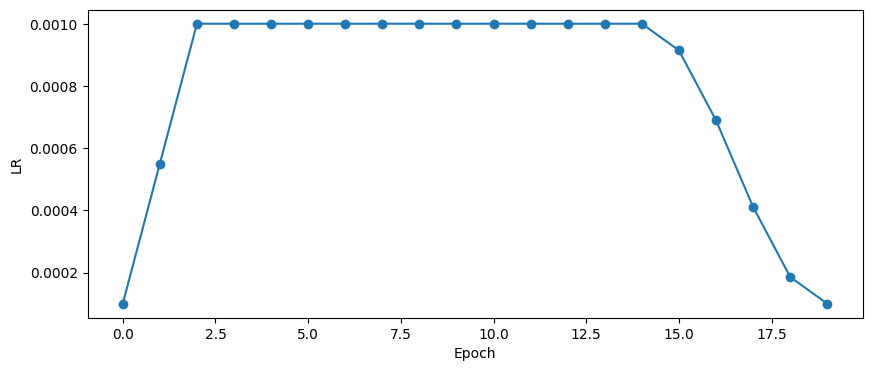

In [51]:
LR_START = 1e-4
LR_MAX = 1e-3
LR_MIN = 1e-4
LR_RAMPUP_EPOCHS = 2
LR_SUSTAIN_EPOCHS = 12
EPOCHS = 20

def lrfn(epoch):
    if epoch < LR_RAMPUP_EPOCHS:
        lr = (LR_MAX - LR_START) / LR_RAMPUP_EPOCHS * epoch + LR_START
    elif epoch < LR_RAMPUP_EPOCHS + LR_SUSTAIN_EPOCHS:
        lr = LR_MAX
    else:
        decay_total_epochs = EPOCHS - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS - 1
        decay_epoch_index = epoch - LR_RAMPUP_EPOCHS - LR_SUSTAIN_EPOCHS
        phase = math.pi * decay_epoch_index / decay_total_epochs
        cosine_decay = 0.5 * (1 + math.cos(phase))
        lr = (LR_MAX - LR_MIN) * cosine_decay + LR_MIN
    return lr


rng = [i for i in range(EPOCHS)]
lr_y = [lrfn(x) for x in rng]
plt.figure(figsize=(10, 4))
plt.plot(rng, lr_y, '-o')
plt.xlabel('Epoch'); plt.ylabel('LR')
print("Learning rate schedule: {:.3g} to {:.3g} to {:.3g}". \
      format(lr_y[0], max(lr_y), lr_y[-1]))
LR_Scheduler = tf.keras.callbacks.LearningRateScheduler(lrfn, verbose=True)

In [52]:
from tensorflow.keras.callbacks import EarlyStopping
class CFG:
    epochs = 20
    batch_size = 256
    LR_Scheduler = [LR_Scheduler]
    optimizer = Adam(learning_rate=1e-3)

    # early_stopping = EarlyStopping(
    #     monitor='val_root_mean_squared_error',  # 正しいメトリック名を指定
    #     patience=5,  # 改善が見られない場合、5エポック後に停止
    #     restore_best_weights=True  # 最良の重みに戻す
    # )
    conf = ModelConfig(auto_imputation=False,
                        auto_discrete=False,
                        auto_discard_unique=True,
                        categorical_columns='auto',
                        apply_gbm_features=True,
                        fixed_embedding_dim=True,
                        embeddings_output_dim=4,
                        embedding_dropout=0.3,
                        nets=['dnn_nets'] + ['cin_nets'] + ['afm_nets'] ,
                        dnn_params={
                            'hidden_units': ((1024, 0.3, True),
                                            (512, 0.5, True),
                                            (128, 0.5, True),
                                            (8, 0.3, True)),
                            'dnn_activation': 'relu',
                        },
                        cin_params={
                            'cross_layer_size': (128, 128, 64),
                            'cin_activation': 'relu',
                            # 'use_residual': True,
                        },
                        afm_params={
                            'attention_factor': 4,
                            'dropout_rate': 0.3
                        },
                        stacking_op='concat',
                        output_use_bias=False,
                        optimizer=optimizer,
                        task='regression',
                        loss="auto",
                        metrics=['RootMeanSquaredError'],
                        # earlystopping_patience=1,
                        )

In [53]:
from sklearn.preprocessing import StandardScaler
def train_dnn(train,conf):
    test_rmse_scores = []
    pred_list = []
    for fold in tqdm(range(5)):
        os.makedirs(f"/kaggle/working/nn_models/fold{fold}", exist_ok=True)
        os.makedirs(f"/tmp/workdir/kaggle/working/nn_models/fold{fold}", exist_ok=True)

        train_df = train[train["fold"] != fold]
        test_df = train[train["fold"] == fold]

        X_train = train_df.drop("fold", axis=1)
        y_train = train_df["utility_agent1"]
        X_test = test_df.drop("fold", axis=1)
        y_test = test_df['utility_agent1']

        # scaler = joblib.load(f"/content/drive/MyDrive/um-game-playing-strength-of-mcts-variants/prepro/scaler_fold{fold}.pickle")
        # kmeans = joblib.load(f"/content/drive/MyDrive/um-game-playing-strength-of-mcts-variants/prepro/kmeans_fold{fold}.pickle")
        # target_mean_list = joblib.load(f"/content/drive/MyDrive/um-game-playing-strength-of-mcts-variants/prepro/map_fold{fold}.pickle")

        numeric_features = X_train.select_dtypes(include=['number']).columns
        scaler = StandardScaler()
        X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
        X_test[numeric_features] = scaler.transform(X_test[numeric_features])

        # X_train["cluster"] = kmeans.predict(X_train[cluster_column])
        # X_test["cluster"] = kmeans.predict(X_test[cluster_column])

        # X_train["cluster"] = X_train["cluster"].astype("category")
        # X_test["cluster"] = X_test["cluster"].astype("category")

        # X_train,target_mean_list = get_target_encoding_cluster_train(X_train)
        # X_train = get_target_encoding_cluster_test(X_train,target_mean_list)
        # X_test = get_target_encoding_cluster_test(X_test,target_mean_list)

        X_train = X_train.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)
        X_test = X_test.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)

        K.clear_session()

        nn_model = DeepTable(config=CFG.conf)
        nn_model.fit(X_train, y_train,
                  validation_data=(X_test, y_test),
                  callbacks=[CFG.LR_Scheduler],
                  # callbacks=[CFG.early_stopping],
                  batch_size=CFG.batch_size, epochs=CFG.epochs, verbose=2)

        # filename = f'/content/drive/MyDrive/um-game-playing-strength-of-mcts-variants/baseline24/nn_model_fold{fold}.pkl'
        # with open(filename, 'wb') as wb:
        #     pickle.dump(nn_model, wb)

        nn_model.save(f'/kaggle/working/nn_models/fold{fold}')
        os.system(f'cp -r /kaggle/working/nn_models/fold{fold}/* /tmp/workdir/kaggle/working/nn_models/fold{fold}/')

        with K.name_scope(CFG.optimizer.__class__.__name__):
          for j, var in enumerate(CFG.optimizer.weights):
              name = 'variable{}'.format(j)
              CFG.optimizer.weights[j] = tf.Variable(var, name=name)
        CFG.conf = CFG.conf._replace(optimizer=CFG.optimizer)


        y_test_pred = nn_model.predict(X_test, verbose=1, batch_size=512).flatten().clip(-1,1)

        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

        test_rmse_scores.append(test_rmse)
        pred_list.append(y_test_pred)

        print(f"Fold {fold+1} Test RMSE: {test_rmse:.3f}")


    print("\n--- Final Mean Scores ---")
    print(f"Mean Test RMSE: {np.mean(test_rmse_scores)}")
    results_df = pd.DataFrame({
        'Fold': np.arange(1, 6),
        'Test RMSE': test_rmse_scores
    })

    print("\n=== KFold RMSE Results ===")

    return pred_list

In [54]:
pred_list = train_dnn(train,CFG.conf)

  0%|          | 0/5 [00:00<?, ?it/s]

11-14 02:09:22 I deeptables.m.deeptable.py 338 - X.Shape=(193642, 573), y.Shape=(193642,), batch_size=256, config=ModelConfig(name='conf-1', nets=['dnn_nets', 'afm_nets', 'cin_nets'], categorical_columns='auto', exclude_columns=[], task='regression', pos_label=None, metrics=['RootMeanSquaredError'], auto_categorize=False, cat_exponent=0.5, cat_remain_numeric=True, auto_encode_label=True, auto_imputation=False, auto_scale=False, auto_discrete=False, auto_discard_unique=True, apply_gbm_features=True, gbm_params={}, gbm_feature_type='embedding', fixed_embedding_dim=True, embeddings_output_dim=4, embeddings_initializer='uniform', embeddings_regularizer=None, embeddings_activity_regularizer=None, dense_dropout=0, embedding_dropout=0.3, stacking_op='concat', output_use_bias=False, apply_class_weight=False, optimizer=<keras.src.optimizers.legacy.adam.Adam object at 0x7baed7bf95d0>, loss='auto', dnn_params={'hidden_units': ((1024, 0.3, True), (512, 0.5, True), (128, 0.5, True), (8, 0.3, True))

11-14 02:09:23 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



11-14 02:09:24 I deeptables.m.preprocessor.py 263 - Preparing features...
11-14 02:09:25 I deeptables.m.preprocessor.py 338 - Preparing features taken 1.2874913215637207s
11-14 02:09:25 I deeptables.m.preprocessor.py 390 - Categorical encoding...
11-14 02:09:26 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 0.8029367923736572s
11-14 02:09:26 I deeptables.m.preprocessor.py 436 - Extracting GBM features...
11-14 02:09:27 I hypernets.t.sklearn_ex.py 640 - LightGBM task:regression
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.958781 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35252
[LightGBM] [Info] Number of data points in the train set: 193642, number of used features: 566
[LightGBM] [Info] Start training from score 0.050299
11-14 02:10:07 I deeptables.m.preprocessor.py 447 - Extracting gbm features taken 40.928369998931885s
11-14 02:10:08 I deeptables.m.preprocessor.py 198 - fi

 20%|██        | 1/5 [18:16<1:13:06, 1096.65s/it]

...

Fold 4 Test RMSE: 0.418
11-14 03:22:45 I deeptables.m.deeptable.py 338 - X.Shape=(164822, 573), y.Shape=(164822,), batch_size=256, config=ModelConfig(name='conf-1', nets=['dnn_nets', 'afm_nets', 'cin_nets'], categorical_columns='auto', exclude_columns=[], task='regression', pos_label=None, metrics=['RootMeanSquaredError'], auto_categorize=False, cat_exponent=0.5, cat_remain_numeric=True, auto_encode_label=True, auto_imputation=False, auto_scale=False, auto_discrete=False, auto_discard_unique=True, apply_gbm_features=True, gbm_params={}, gbm_feature_type='embedding', fixed_embedding_dim=True, embeddings_output_dim=4, embeddings_initializer='uniform', embeddings_regularizer=None, embeddings_activity_regularizer=None, dense_dropout=0, embedding_dropout=0.3, stacking_op='concat', output_use_bias=False, apply_class_weight=False, optimizer=<keras.src.optimizers.legacy.adam.Adam object at 0x7baed7bf95d0>, loss='auto', dnn_params={'hidden_units': ((1024, 0.3, True), (512, 0.5, True), (128, 0.5

11-14 03:22:47 W hypernets.t.cache.py 210 - AttributeError: Can't pickle local object 'make_gradient_clipnorm_fn.<locals>.<lambda>'
Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/cache.py", line 165, in _cache_call
    cache_key = tb.data_hasher()(key_items)
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 20, in __call__
    for x in self._iter_data(data):
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 58, in _iter_data
    yield from self._iter_data(v)
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 53, in _iter_data
    yield from self._iter_data(x)
  File "/opt/conda/lib/python3.10/site-packages/hypernets/tabular/data_hasher.py", line 61, in _iter_data
    pickle.dump(data, buf, protocol=pickle.HIGHEST_PROTOCOL)



11-14 03:22:48 I deeptables.m.preprocessor.py 263 - Preparing features...
11-14 03:22:49 I deeptables.m.preprocessor.py 338 - Preparing features taken 1.0852112770080566s
11-14 03:22:49 I deeptables.m.preprocessor.py 390 - Categorical encoding...
11-14 03:22:50 I deeptables.m.preprocessor.py 395 - Categorical encoding taken 0.6326584815979004s
11-14 03:22:50 I deeptables.m.preprocessor.py 436 - Extracting GBM features...
11-14 03:22:50 I hypernets.t.sklearn_ex.py 640 - LightGBM task:regression
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.837266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34907
[LightGBM] [Info] Number of data points in the train set: 164822, number of used features: 570
[LightGBM] [Info] Start training from score 0.035321
11-14 03:23:22 I deeptables.m.preprocessor.py 447 - Extracting gbm features taken 32.902902603149414s
11-14 03:23:23 I deeptables.m.preprocessor.py 198 - fi

100%|██████████| 5/5 [1:30:32<00:00, 1086.45s/it]

Fold 5 Test RMSE: 0.558

--- Final Mean Scores ---
Mean Test RMSE: 0.4581942558288574

=== KFold RMSE Results ===


In [55]:
# Check load model
def load_model(paths):
    models = []
    for fold in sorted(os.listdir(paths)):
        path = os.path.join(paths, fold)
        for file in os.listdir(path):
            if file.endswith('.h5'):
                models.append(DeepTable.load(path, file))
            elif file.endswith('.cbm'):
                print('Load model from:', path+'/'+file)
                models.append(CatBoostRegressor().load_model(path+'/'+file))
    return models

nn_models = load_model("/kaggle/working/nn_models")
print('nn_models:', nn_models,'\n')

11-14 03:48:41 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold0/dnn_nets+afm_nets+cin_nets.h5.
2 Physical GPUs, 2 Logical GPUs
11-14 03:48:44 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold1/dnn_nets+afm_nets+cin_nets.h5.
2 Physical GPUs, 2 Logical GPUs
11-14 03:48:46 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold2/dnn_nets+afm_nets+cin_nets.h5.
2 Physical GPUs, 2 Logical GPUs
11-14 03:48:50 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold3/dnn_nets+afm_nets+cin_nets.h5.
2 Physical GPUs, 2 Logical GPUs
11-14 03:48:54 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold4/dnn_nets+afm_nets+cin_nets.h5.
2 Physical GPUs, 2 Logical GPUs
nn_models: [<deeptables.models.deeptable.DeepTable object at 0x7baed7bfa200>, <deeptables.models.deeptable.DeepTable object at 0x7baebd4dddb0>, <deeptables.models.deeptable.DeepTable object at 0x

In [65]:
fold = 3

train_df = train[train["fold"] != fold]
test_df = train[train["fold"] == fold]

X_train = train_df.drop("fold", axis=1)
y_train = train_df["utility_agent1"]
X_test = test_df.drop("fold", axis=1)
y_test = test_df['utility_agent1']
numeric_features = X_train.select_dtypes(include=['number']).columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])
X_train = X_train.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)
X_test = X_test.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)
y = nn_models[fold].predict(X_test, verbose=1, batch_size=512)
print(np.sqrt(mean_squared_error(y_test, y)))

11-14 03:53:10 I deeptables.m.deeptable.py 685 - Perform prediction...
11-14 03:53:10 I deeptables.m.preprocessor.py 244 - Transform [X]...
11-14 03:53:11 I deeptables.m.preprocessor.py 251 - transform_X taken 1.1395914554595947s
11-14 03:53:11 I deeptables.m.deepmodel.py 130 - Performing predictions...
11-14 03:53:11 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=512, shuffle=False, drop_remainder=False
83/83 [==============================] - 5s 32ms/step
11-14 03:53:16 I deeptables.m.deeptable.py 559 - predict_proba taken 5.988309383392334s
0.41777056


(array([2.000e+00, 2.000e+00, 9.000e+00, 2.600e+01, 7.900e+01, 3.240e+02,
        6.170e+02, 6.790e+02, 6.620e+02, 6.700e+02, 7.750e+02, 7.980e+02,
        7.470e+02, 7.870e+02, 8.470e+02, 8.150e+02, 8.810e+02, 9.650e+02,
        1.114e+03, 1.195e+03, 1.299e+03, 1.564e+03, 1.731e+03, 2.031e+03,
        2.373e+03, 2.332e+03, 2.175e+03, 1.936e+03, 1.658e+03, 1.438e+03,
        1.254e+03, 1.133e+03, 1.025e+03, 9.050e+02, 8.310e+02, 7.280e+02,
        6.700e+02, 6.430e+02, 6.650e+02, 6.920e+02, 7.490e+02, 7.460e+02,
        6.620e+02, 5.090e+02, 2.910e+02, 1.390e+02, 6.400e+01, 1.500e+01,
        7.000e+00, 3.000e+00]),
 array([-1.13220656, -1.086411  , -1.04061544, -0.99481988, -0.94902432,
        -0.90322876, -0.8574332 , -0.81163764, -0.76584208, -0.72004652,
        -0.67425096, -0.6284554 , -0.58265984, -0.53686422, -0.49106869,
        -0.44527313, -0.39947757, -0.35368201, -0.30788645, -0.26209086,
        -0.21629532, -0.17049976, -0.12470419, -0.07890863, -0.03311307,
         0.

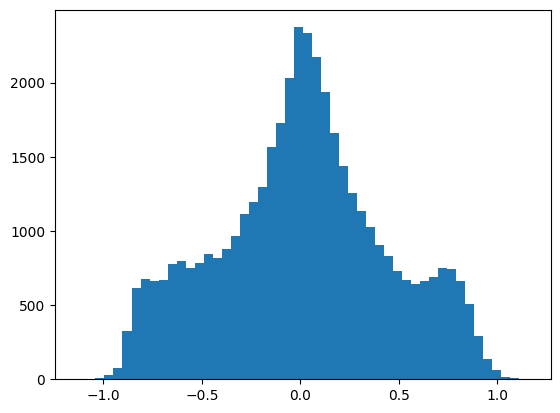

In [66]:
plt.hist(y,bins=50)

# アンサンブル

In [65]:
def create_2stgpred(data,modellist_1st,modellist_2nd,fold):
    model1 = modellist_1st[fold]
    model2 = modellist_2nd[fold]
    pred_df = pd.DataFrame(data)
    pred_df["original_index"] = data.index

    y_test_pred = model1.predict(data)

    pred_df["pred"] = y_test_pred
    pred_df["pred_prob"] = np.max(model1.predict_proba(data), axis=1)
    pred_df_1st = pred_df[(pred_df['pred'].isin([0, 1])) & (pred_df['pred_prob'] >= 0.8)]
    pred_df_2st = pred_df[~((pred_df['pred'].isin([0, 1])) & (pred_df['pred_prob'] >= 0.8))]
    X_test_2nd = pred_df_2st.drop(["pred","pred_prob","original_index"], axis=1)

    y_test_pred = model2.predict(X_test_2nd)
    pred_df_2st["pred"] = y_test_pred
    pred_df_1st["pred"] = pred_df_1st["pred"].apply(lambda x: -1 if x == 0 else 1)

    pred_df = pd.concat([pred_df_1st, pred_df_2st])

    df_combine = pred_df.sort_values("original_index")
    return df_combine["pred"]

In [66]:
def create_3tarpred(data,modellist_win,modellist_loss,modellist_draw,fold):
    model_win = modellist_win[fold]
    model_loss = modellist_loss[fold]
    model_draw = modellist_draw[fold]
    pred_win = model_win.predict(data)
    pred_loss = model_loss.predict(data)
    pred_draw = model_draw.predict(data)
    pred = (pred_win-pred_loss)/(pred_win+pred_loss+pred_draw)
    return pred

In [26]:
import joblib

In [27]:
models_simple_cat_0 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_normal_seed0_fold{i}.pickle') for i in range(5)]
models_simple_cat_1 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_normal_seed1_fold{i}.pickle') for i in range(5)]
models_simple_cat_2 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_normal_seed2_fold{i}.pickle') for i in range(5)]

models_simple_lgb_0 = [joblib.load(f'/kaggle/input/mcts-basemodels/lgb_model_seed0_fold{i}.pickle') for i in range(5)]
models_simple_lgb_1 = [joblib.load(f'/kaggle/input/mcts-basemodels/lgb_model_seed1_fold{i}.pickle') for i in range(5)]
models_simple_lgb_2 = [joblib.load(f'/kaggle/input/mcts-basemodels/lgb_model_seed2_fold{i}.pickle') for i in range(5)]

models_unbalance_cat_1st_0 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_unbalance_1st_seed0_fold{i}.pickle') for i in range(5)]
models_unbalance_cat_2nd_0 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_unbalance_2nd_seed0_fold{i}.pickle') for i in range(5)]
models_unbalance_cat_1st_1 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_unbalance_1st_seed1_fold{i}.pickle') for i in range(5)]
models_unbalance_cat_2nd_1 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_unbalance_2nd_seed1_fold{i}.pickle') for i in range(5)]
models_unbalance_cat_1st_2 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_unbalance_1st_seed2_fold{i}.pickle') for i in range(5)]
models_unbalance_cat_2nd_2 = [joblib.load(f'/kaggle/input/mcts-basemodels/cat_model_unbalance_2nd_seed2_fold{i}.pickle') for i in range(5)]

models_target_win_0 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_win_seed0_fold{i}.pickle") for i in range(5)]
models_target_loss_0 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_loss_seed0_fold{i}.pickle") for i in range(5)]
models_target_draw_0 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_draw_seed0_fold{i}.pickle") for i in range(5)]
models_target_win_1 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_win_seed1_fold{i}.pickle") for i in range(5)]
models_target_loss_1 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_loss_seed1_fold{i}.pickle") for i in range(5)]
models_target_draw_1 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_draw_seed1_fold{i}.pickle") for i in range(5)]
models_target_win_2 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_win_seed2_fold{i}.pickle") for i in range(5)]
models_target_loss_2 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_loss_seed2_fold{i}.pickle") for i in range(5)]
models_target_draw_2 = [joblib.load(f"/kaggle/input/mcts-basemodels/cat_model_target_draw_seed2_fold{i}.pickle") for i in range(5)]

In [28]:
for fold in range(5):
    os.makedirs(f"/tmp/workdir/kaggle/working/nn_models/fold{fold}", exist_ok=True)
    os.makedirs(f"/kaggle/working/nn_models/fold{fold}", exist_ok=True)
    os.system(f'cp -r /kaggle/input/mcts-deeptable1/fold{fold}/* /tmp/workdir/kaggle/working/nn_models/fold{fold}/')
    os.system(f'cp -r /kaggle/input/mcts-deeptable1/fold{fold}/* /kaggle/working/nn_models/fold{fold}/')

In [29]:
def load_model(paths):
    models = []
    for fold in sorted(os.listdir(paths)):
        path = os.path.join(paths, fold)
        for file in os.listdir(path):
            if file.endswith('.h5'):
                models.append(DeepTable.load(path, file))
            elif file.endswith('.cbm'):
                print('Load model from:', path+'/'+file)
                models.append(CatBoostRegressor().load_model(path+'/'+file))
    return models

nn_models = load_model("/kaggle/working/nn_models")

11-17 12:14:24 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold0/dnn_netsafm_netscin_nets.h5.
Physical devices cannot be modified after being initialized
11-17 12:14:29 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold1/dnn_netsafm_netscin_nets.h5.
Physical devices cannot be modified after being initialized
11-17 12:14:32 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold2/dnn_netsafm_netscin_nets.h5.
Physical devices cannot be modified after being initialized
11-17 12:14:36 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold3/dnn_netsafm_netscin_nets.h5.
Physical devices cannot be modified after being initialized
11-17 12:14:40 I deeptables.m.deeptable.py 818 - Load model from: /kaggle/working/nn_models/fold4/dnn_netsafm_netscin_nets.h5.
Physical devices cannot be modified after being initialized


In [72]:
mapping_rules = [
    (-1.0, -0.93, -1.0),
    (-0.93, -0.87, -0.93),
    (-0.87, -0.73, -0.87),
    (-0.73, -0.6, -0.73),
    (-0.6, -0.47, -0.6),
    (-0.47, -0.33, -0.47),
    (-0.33, -0.2, -0.33),
    (-0.2, -0.13, -0.2),
    (-0.13, -0.06, -0.13),
    (-0.03, 0.0, 0.0),
    (0.0, 0.03, 0.0),
    (0.06, 0.13, 0.13),
    (0.13, 0.2, 0.2),
    (0.2, 0.33, 0.33),
    (0.33, 0.47, 0.47),
    (0.47, 0.6, 0.6),
    (0.6, 0.73, 0.73),
    (0.73, 0.87, 0.87),
    (0.87, 0.93, 0.93),
    (0.93, 1.0, 1.0)
]

mapping_rules = [
    (-1.0, -0.93, -1.0),
    # (-0.93, -0.87, -0.93),
    # (-0.87, -0.73, -0.87),
    # (-0.13, -0.06, -0.13),
    (-0.03, 0.0, 0.0),
    (0.0, 0.03, 0.0),
    # (0.06, 0.13, 0.13),
    # (0.87, 0.93, 0.93),
    (0.93, 1.0, 1.0)
]

# マッピング関数を定義
def map_value(value, rules):
    for lower, upper, mapped_value in rules:
        if lower <= value < upper:
            return mapped_value
    return value  # どの範囲にも該当しない場合は元の値を返す



In [33]:
scalers = [joblib.load(f'/kaggle/input/mcts-scaler/scaler_fold{i}.pickle') for i in range(5)]

In [50]:
X_test_copy = X_test.copy()

In [51]:
X_test_copy["f"] = "f"

In [52]:
X_test

,Stochastic,Asymmetric,PlayersWithDirections,Cooperation,Shape,SquareShape,HexShape,TriangleShape,DiamondShape,RectangleShape,...,DurationTurnsStdDev_PlayoutsPerSecond_ratio,DurationTurnsStdDev_MovesPerSecond_ratio,DurationTurnsNotTimeouts_PlayoutsPerSecond_ratio,DurationTurnsNotTimeouts_MovesPerSecond_ratio,DecisionMoves_PlayoutsPerSecond_ratio,DecisionMoves_MovesPerSecond_ratio,GameTreeComplexity_PlayoutsPerSecond_ratio,GameTreeComplexity_MovesPerSecond_ratio,StateTreeComplexity_PlayoutsPerSecond_ratio,StateTreeComplexity_MovesPerSecond_ratio
6050,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,22.503216,0.009324,0.643672,0.000267,0.049628,0.000021,108.859505,0.045107,5.053596,0.002094
6051,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,22.503216,0.009324,0.643672,0.000267,0.049628,0.000021,108.859505,0.045107,5.053596,0.002094
6052,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,22.503216,0.009324,0.643672,0.000267,0.049628,0.000021,108.859505,0.045107,5.053596,0.002094
6053,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,22.503216,0.009324,0.643672,0.000267,0.049628,0.000021,108.859505,0.045107,5.053596,0.002094
6054,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,22.503216,0.009324,0.643672,0.000267,0.049628,0.000021,108.859505,0.045107,5.053596,0.002094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232891,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.196503,0.000688,0.265612,0.000930,0.000996,0.000003,0.327851,0.001147,0.074491,0.000261
232892,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.196503,0.000688,0.265612,0.000930,0.000996,0.000003,0.327851,0.001147,0.074491,0.000261
232893,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.196503,0.000688,0.265612,0.000930,0.000996,0.000003,0.327851,0.001147,0.074491,0.000261
232894,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.196503,0.000688,0.265612,0.000930,0.000996,0.000003,0.327851,0.001147,0.074491,0.000261


In [67]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
lgb_preds = []
cat_preds = []
unbal_preds = []
targ_preds = []
nn_preds = []
for fold in tqdm(range(5)):

    train_df = train[train["fold"] != fold]
    test_df = train[train["fold"] == fold]

    X_train = train_df.drop("fold", axis=1)
    X_test = test_df.drop("fold", axis=1)
    y_test = test_df['utility_agent1']
    X_train = X_train.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)
    X_test = X_test.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)

    # lgb simple
    pred = models_simple_lgb_0[fold].predict(X_test)
    pred2 = models_simple_lgb_1[fold].predict(X_test)
    pred3 = models_simple_lgb_2[fold].predict(X_test)

    pred_lgb = (pred*0.4+pred2*0.3+pred3*0.3)
    lgb_preds.append(pred_lgb)

    # catboost simple
    pred = models_simple_cat_0[fold].predict(X_test)
    pred2 = models_simple_cat_1[fold].predict(X_test)
    pred3 = models_simple_cat_2[fold].predict(X_test)

    pred_cat = (pred*0.35+pred2*0.35+pred3*0.3)
    cat_preds.append(pred_cat)

    # catboost unbalance

    pred_unbalance_0 = create_2stgpred(X_test,models_unbalance_cat_1st_0,models_unbalance_cat_2nd_0,fold)
    pred_unbalance_1 = create_2stgpred(X_test,models_unbalance_cat_1st_1,models_unbalance_cat_2nd_1,fold)
    pred_unbalance_2 = create_2stgpred(X_test,models_unbalance_cat_1st_2,models_unbalance_cat_2nd_2,fold)

    pred_unbalance = pred_unbalance_0*0.4 + pred_unbalance_1*0.3 + pred_unbalance_2*0.3
    unbal_preds.append(pred_unbalance)

    # catboost 3target
    pred_target_0 = create_3tarpred(X_test,models_target_win_0,models_target_loss_0,models_target_draw_0,fold)
    pred_target_1 = create_3tarpred(X_test,models_target_win_1,models_target_loss_1,models_target_draw_1,fold)
    pred_target_2 = create_3tarpred(X_test,models_target_win_2,models_target_loss_2,models_target_draw_2,fold)
    pred_target = pred_target_0*0.2 + pred_target_1*0.4 + pred_target_2*0.4
    targ_preds.append(pred_target)

    pred_stack = (pred_unbalance*0.2 + pred_cat*0.2 + pred_target*0.5 + pred_lgb*0.1)

    numeric_features = X_train.select_dtypes(include=['number']).columns
    # scaler = scalers[fold]
    # X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test[numeric_features] = scalers[fold].transform(X_test[numeric_features])

    pred_nn = nn_models[fold].predict(X_test, verbose=1, batch_size=512)
    pred_nn = pred_nn.flatten()*1.1

    nn_preds.append(pred_nn)

    test_rmse = np.sqrt(mean_squared_error(y_test, (pred_stack*0.9 + pred_nn*0.1).clip(-1,1)))
    print(test_rmse)


  0%|          | 0/5 [00:00<?, ?it/s]

11-17 12:52:06 I deeptables.m.deeptable.py 685 - Perform prediction...
11-17 12:52:06 I deeptables.m.preprocessor.py 244 - Transform [X]...
11-17 12:52:07 I deeptables.m.preprocessor.py 251 - transform_X taken 1.2001266479492188s
11-17 12:52:07 I deeptables.m.deepmodel.py 130 - Performing predictions...
11-17 12:52:07 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=512, shuffle=False, drop_remainder=False
78/78 [==============================] - 2s 29ms/step
11-17 12:52:10 I deeptables.m.deeptable.py 559 - predict_proba taken 3.700136184692383s


 20%|██        | 1/5 [00:40<02:42, 40.67s/it]

0.4239106617583823
11-17 12:52:49 I deeptables.m.deeptable.py 685 - Perform prediction...
11-17 12:52:49 I deeptables.m.preprocessor.py 244 - Transform [X]...
11-17 12:52:50 I deeptables.m.preprocessor.py 251 - transform_X taken 1.200312852859497s
11-17 12:52:50 I deeptables.m.deepmodel.py 130 - Performing predictions...
11-17 12:52:50 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=512, shuffle=False, drop_remainder=False
77/77 [==============================] - 2s 29ms/step
11-17 12:52:53 I deeptables.m.deeptable.py 559 - predict_proba taken 3.707341194152832s


 40%|████      | 2/5 [01:23<02:06, 42.13s/it]

...

0.4144749255141908
11-17 12:54:08 I deeptables.m.deeptable.py 685 - Perform prediction...
11-17 12:54:08 I deeptables.m.preprocessor.py 244 - Transform [X]...
11-17 12:54:09 I deeptables.m.preprocessor.py 251 - transform_X taken 1.2899885177612305s
11-17 12:54:09 I deeptables.m.deepmodel.py 130 - Performing predictions...
11-17 12:54:09 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=512, shuffle=False, drop_remainder=False
83/83 [==============================] - 2s 29ms/step
11-17 12:54:12 I deeptables.m.deeptable.py 559 - predict_proba taken 4.0210864543914795s


 80%|████████  | 4/5 [02:43<00:40, 40.66s/it]

0.3958544756154983
11-17 12:55:03 I deeptables.m.deeptable.py 685 - Perform prediction...
11-17 12:55:03 I deeptables.m.preprocessor.py 244 - Transform [X]...
11-17 12:55:05 I deeptables.m.preprocessor.py 251 - transform_X taken 2.045750856399536s
11-17 12:55:05 I deeptables.m.deepmodel.py 130 - Performing predictions...
11-17 12:55:05 I deeptables.u.dataset_generator.py 250 - create dataset generator with _TFDGForPandas, batch_size=512, shuffle=False, drop_remainder=False
134/134 [==============================] - 4s 29ms/step
11-17 12:55:10 I deeptables.m.deeptable.py 559 - predict_proba taken 6.637043714523315s


100%|██████████| 5/5 [03:41<00:00, 44.23s/it]

0.5554535381534382


  0%|          | 0/5 [00:00<?, ?it/s]

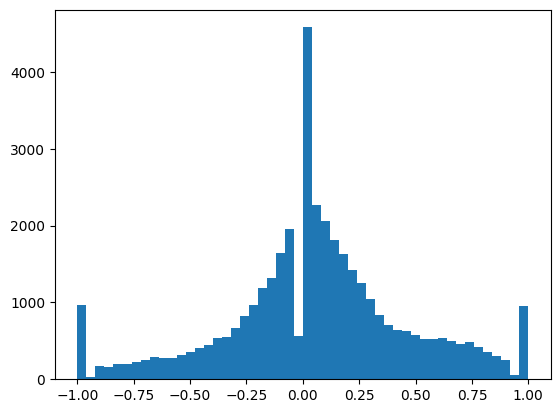

 20%|██        | 1/5 [00:00<00:03,  1.05it/s]

0.42647041303764


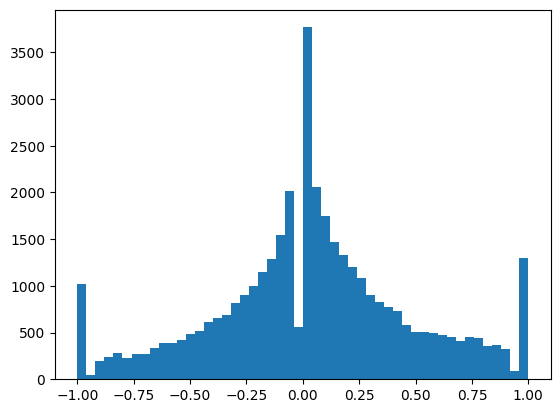

 40%|████      | 2/5 [00:01<00:02,  1.04it/s]

0.40266750002825463


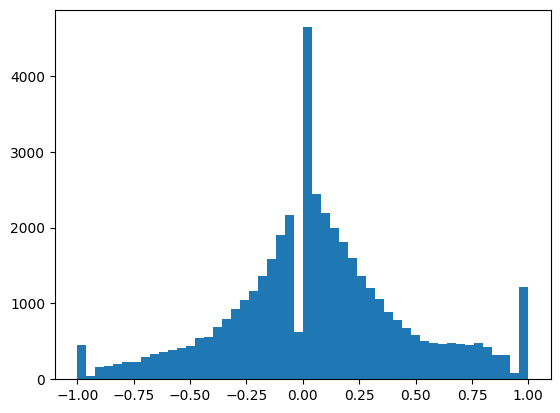

 60%|██████    | 3/5 [00:02<00:01,  1.04it/s]

0.414727793521491


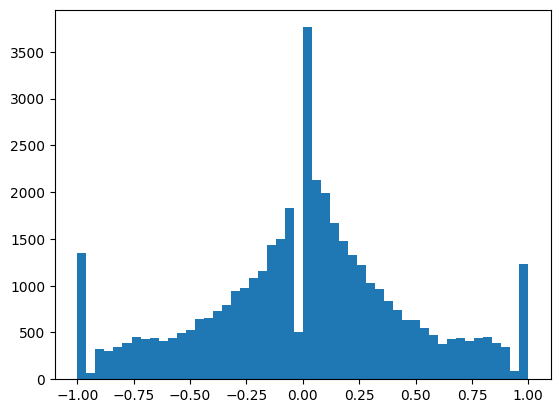

 80%|████████  | 4/5 [00:03<00:00,  1.04it/s]

0.39413762670047603


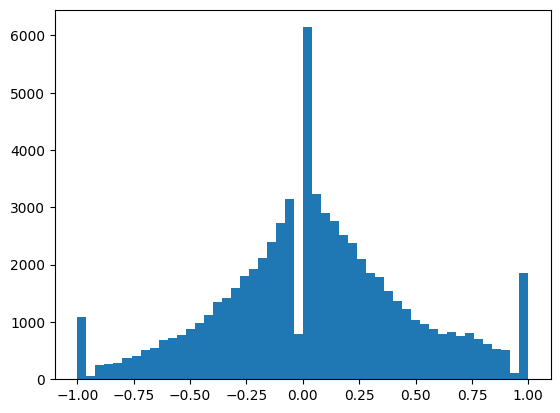

100%|██████████| 5/5 [00:04<00:00,  1.04it/s]

0.5521053094806414


In [73]:
for fold in tqdm(range(5)):
    train_df = train[train["fold"] != fold]
    test_df = train[train["fold"] == fold]
    X_train = train_df.drop("fold", axis=1)
    X_test = test_df.drop("fold", axis=1)
    y_test = test_df['utility_agent1']
    pred_lgb = lgb_preds[fold]*1.1
    pred_cat = cat_preds[fold]*1.1
    pred_unb = unbal_preds[fold]*1.1
    pred_tar = targ_preds[fold]*1.1
    pred_nn = nn_preds[fold]*1.1
    pred_stack = (pred_unb*0.2 + pred_cat*0.2 + pred_tar*0.5 + pred_lgb*0.1)
    pred = (pred_stack*0.9 + pred_nn*0.1).clip(-1,1)
    pred2 = (pred_stack*0.86 + pred_nn*0.15).clip(-1,1)

    pred_sub = pred*1
    pred = [map_value(v,mapping_rules) for v in pred]
    test_rmse = np.sqrt(mean_squared_error(y_test, pred))
    plt.hist(pred,bins = 50)
    plt.show()
    print(test_rmse)

(array([ 1879.,  2500.,  4474.,  8110., 13904., 15085.,  9640.,  5466.,
         3869.,  3485.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

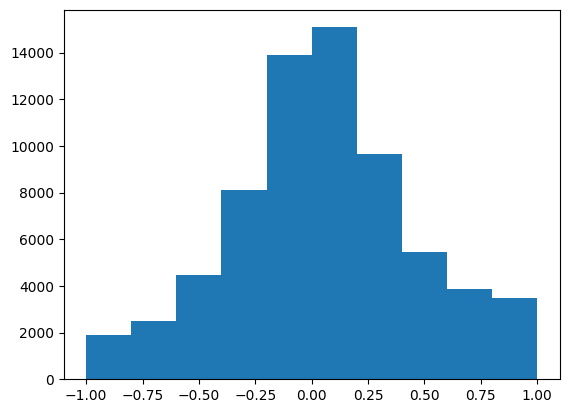

In [36]:
plt.hist((pred_stack*0.9 + (pred_nn.flatten()*1.1)*0.1).clip(-1,1))

In [66]:
for fold in tqdm(range(5)):

    train_df = train[train["fold"] != fold]
    test_df = train[train["fold"] == fold]

    X_train = train_df.drop("fold", axis=1)
    X_test = test_df.drop("fold", axis=1)
    y_test = test_df['utility_agent1']
    X_train = X_train.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)
    X_test = X_test.drop(['utility_agent1','num_losses_agent1','num_wins_agent1', 'num_draws_agent1'], axis=1)

    numeric_features = X_train.select_dtypes(include=['number']).columns
    scaler = StandardScaler()
    X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

    filename = f"/kaggle/working/scaler_fold{fold}.pickle"
    with open(filename, mode='wb') as fp:
        pickle.dump(scaler, fp)

100%|██████████| 5/5 [00:16<00:00,  3.23s/it]


In [39]:
numeric_features

Index(['Stochastic', 'Asymmetric', 'PlayersWithDirections', 'Cooperation',
       'Shape', 'SquareShape', 'HexShape', 'TriangleShape', 'DiamondShape',
       'RectangleShape',
       ...
       'DurationTurnsStdDev_PlayoutsPerSecond_ratio',
       'DurationTurnsStdDev_MovesPerSecond_ratio',
       'DurationTurnsNotTimeouts_PlayoutsPerSecond_ratio',
       'DurationTurnsNotTimeouts_MovesPerSecond_ratio',
       'DecisionMoves_PlayoutsPerSecond_ratio',
       'DecisionMoves_MovesPerSecond_ratio',
       'GameTreeComplexity_PlayoutsPerSecond_ratio',
       'GameTreeComplexity_MovesPerSecond_ratio',
       'StateTreeComplexity_PlayoutsPerSecond_ratio',
       'StateTreeComplexity_MovesPerSecond_ratio'],
      dtype='object', length=556)